# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：王源新，YXwang7yuan,24012436

第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [62]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012436"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012436
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [63]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,5630.0
1,流失人数,948.0
2,总体流失率,17.00%
3,平均订单数,2.96
4,订单数中位数,2.0
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均优惠券使用次数,平均使用App时长
0,0-6个月,2150,697,0.32,2.50,1.56,2.99
1,13-24个月,1467,95,0.06,3.70,2.02,2.94
2,24个月以上,429,0,0.00,3.55,1.94,2.87
3,7-12个月,1584,156,0.10,2.75,1.60,2.88


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-6个月,1,659,375,0.57,2.65,可观察
1,0-6个月,0,1491,322,0.22,2.43,可观察
2,7-12个月,1,406,81,0.20,2.67,可观察
3,13-24个月,1,414,52,0.13,3.35,可观察
4,7-12个月,0,1178,75,0.06,2.78,可观察


检查点1A通过：输入文件有效


In [64]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户生命周期任期分组的流失率是否存在显著差异？",
    "behavior_scatter": "用户平均订单数、平均App使用时长与流失率呈现什么相关关系？",
    "ordered_line": "用户流失率如何随用户生命周期任期阶段变化？",
    "composition_chart": "总流失用户中，各用户生命周期分组的人数占比分别是多少？",
}

chart_reasons = {
    "category_bar": "用户生命周期任期TenureGroup为无顺序离散分类，目标横向对比各组流失指标高低，柱状图适配离散类别间数值大小对比，因此选用分类柱状图。",
    "behavior_scatter": "平均订单数、App使用时长、流失率均为连续数值指标，目标挖掘指标间相关规律，散点图适合展示连续变量的关联分布，因此选用行为散点图。",
    "ordered_line": "用户生命周期任期0-6个月、7-12个月、13-24个月、24个月以上存在递进有序层级，目标观察流失率随任期推进的变化趋势，折线图擅长有序序列趋势展示，因此选用有序折线图。",
    "composition_chart": "数据包含各生命周期分组的流失用户分项数值，构成类图表专门用于表达部分与整体的占比关系，可直观拆解流失人群的结构来源，定位核心流失群体。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [65]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )
assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,0-6个月,2150,0.32
1,13-24个月,1467,0.06
2,24个月以上,429,0.00
3,7-12个月,1584,0.10


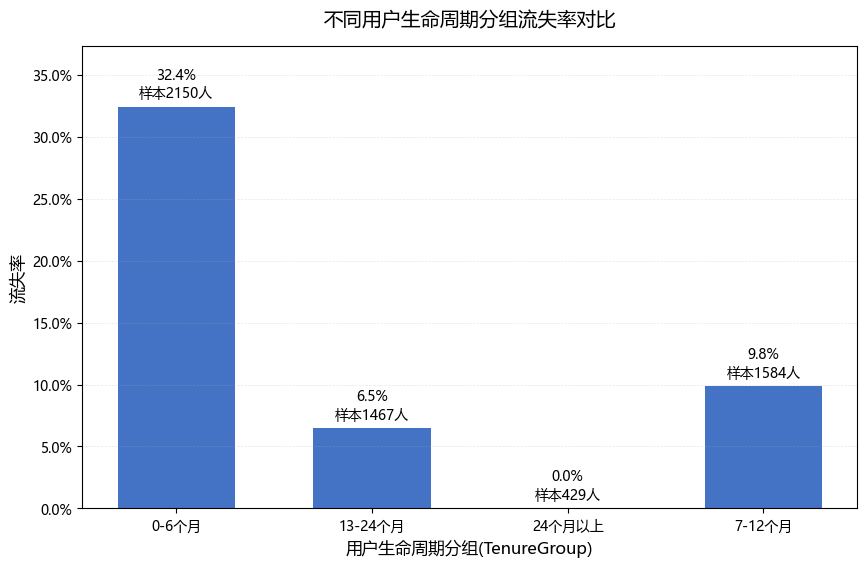

已输出： output\day06_visualization\01_category_bar.png


In [66]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
bars = ax_bar.bar(
    x=category_summary["TenureGroup"],
    height=category_summary["流失率"],
    color="#4472C4",
    width=0.6
)
for bar, user_cnt, churn_rate in zip(bars, category_summary["用户数"], category_summary["流失率"]):
    height = bar.get_height()
    label_text = f"{churn_rate:.1%}\n样本{int(user_cnt)}人"
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.004,
        label_text,
        ha="center", va="bottom", fontsize=10
    )
ax_bar.set_title("不同用户生命周期分组流失率对比", fontsize=14, pad=15)
ax_bar.set_xlabel("用户生命周期分组(TenureGroup)", fontsize=12)
ax_bar.set_ylabel("流失率", fontsize=12)
# Y轴格式改为百分比
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_bar.set_ylim(0, category_summary["流失率"].max() * 1.15)
ax_bar.grid(axis="y", alpha=0.3, linestyle="--")
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户流失风险随生命周期增长呈现明显下降规律，新用户（0-6 个月）是流失高危群体，随着使用时长增加，用户留存稳定性持续提升，使用满 24 个月以上的用户无流失现象。
-
- 证据：0-6 个月新用户：样本 2150 人，流失率 32.4%，为全分组最高；

7-12 个月用户：样本 1584 人，流失率 9.8%，相比新用户流失率大幅下降 22.6%；

13-24 个月用户：样本 1467 人，流失率 6.5%，流失风险进一步小幅降低；

24 个月以上老用户：样本 429 人，流失率 0%，完全无用户流失；

量级差异：  0-6 个月流失率是 13-24 个月分组的 5 倍左右，是 7-12 个月分组的 3 倍以上，各组样本量均超 400，数据具备参考性。
-
- 边界：1.无法证明生命周期长短是导致流失率高低的因果关系，仅能展示两者存在关联，可能存在使用时长以外的混淆变量（如下单频次、投诉、优惠券使用）影响流失
- 2.不能判断 24 个月以上用户零流失现象是否会在更长使用周期后发生改变；
- 3.无法区分同一用户随时间的变化，仅为不同人群的横截面对比，不能反映单个用户从 0 个月过渡到 24 个月的真实留存变化；

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


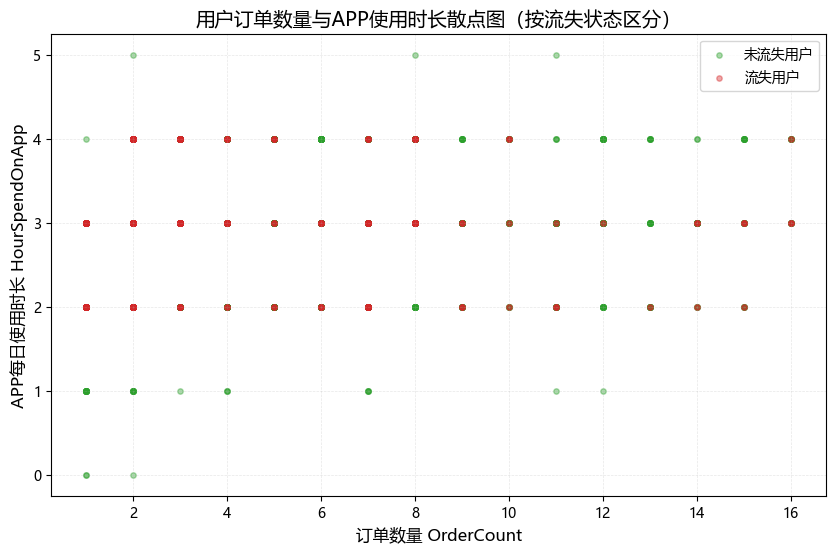

已输出： output\day06_visualization\02_behavior_scatter.png


In [67]:
# TODO：选择两个数值字段，选用数据集真实存在的连续数值列
# X：订单数量 OrderCount  Y：APP每日使用时长 HourSpendOnApp
x_field = "OrderCount"
y_field = "HourSpendOnApp"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按Churn流失状态分组绘制散点，设置透明度alpha
# 未流失用户 Churn=0
df_no_churn = df[df["Churn"] == 0]
ax_scatter.scatter(
    x=df_no_churn[x_field],
    y=df_no_churn[y_field],
    c="#2ca02c",
    alpha=0.4,  # 满足透明度要求
    label="未流失用户",
    s=15
)
# 流失用户 Churn=1
df_churn = df[df["Churn"] == 1]
ax_scatter.scatter(
    x=df_churn[x_field],
    y=df_churn[y_field],
    c="#d62728",
    alpha=0.4,
    label="流失用户",
    s=15
)
# 图表标题、坐标轴、图例、网格
ax_scatter.set_title("用户订单数量与APP使用时长散点图（按流失状态区分）", fontsize=14)
ax_scatter.set_xlabel("订单数量 OrderCount", fontsize=12)
ax_scatter.set_ylabel("APP每日使用时长 HourSpendOnApp", fontsize=12)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3, linestyle="--")

# 保存图片并关闭画布
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：随着订单数量 OrderCount 增加，流失用户（红点）占比逐步降低；低订单量区间流失用户高度聚集，高订单量区间以未流失用户（绿点）为主。
- APP 使用时长较低（0~2 小时）的样本几乎只有留存用户，中等时长（2~4 小时）流失样本大量分布。
-
- 证据：1.订单数量 2~8 的低消费区间，红色流失散点数量远多于绿色留存点；订单数量 10 以上高消费区间，绿色未流失样本数量明显反超。

- 2.APP 每日使用时长 0~1 小时区间几乎不存在流失红点；时长 2~4 小时区间流失用户大量聚集，是流失高发区间。

3.订单数越高、APP 使用时长极低或极高时，用户留存概率更高；中等 APP 时长、低订单量是流失高危组合。

- 边界：相关关系不等于因果关系。
- 仅能证明订单数量、APP 使用时长与流失状态存在相关关系，不能证明二者是用户流失的直接因果；未纳入用户生命周期、投诉、支付方式等混淆变量，无法排除其他因素对流失行为的影响；无法量化两个指标分别对流失风险的影响程度。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [68]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失人数=("Churn", "sum")
    )
    .reset_index()
)
ordered_summary["流失率"] = ordered_summary["流失人数"] / ordered_summary["用户数"]
# 强制按照生命周期指定顺序排序，保证折线有序
ordered_summary[ordered_field] = pd.Categorical(ordered_summary[ordered_field], categories=TENURE_ORDER, ordered=True)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失人数,流失率
0,0-6个月,2150,697,0.32
1,7-12个月,1584,156,0.10
2,13-24个月,1467,95,0.06
3,24个月以上,429,0,0.00


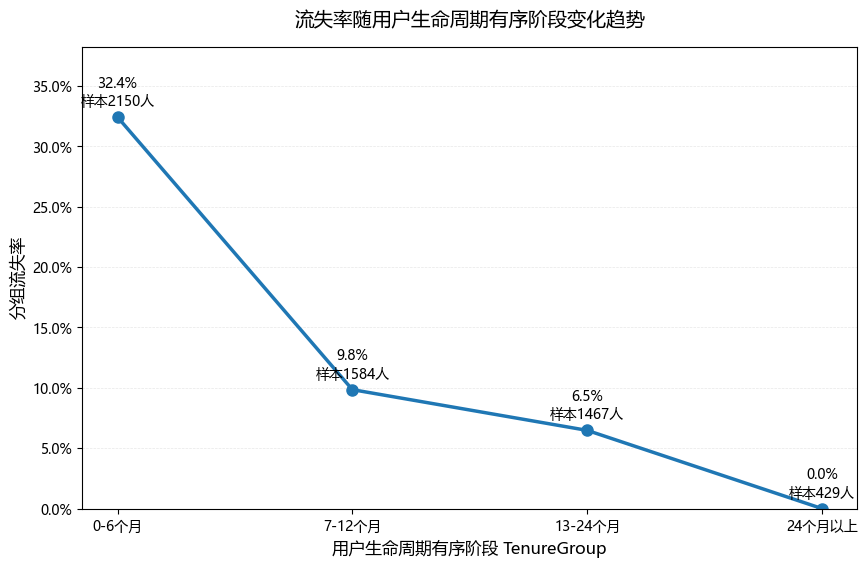

已输出： output\day06_visualization\03_ordered_line.png


In [69]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
line_plot = ax_line.plot(
    ordered_summary[ordered_field],
    ordered_summary["流失率"],
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    markersize=8
)
for idx, row in ordered_summary.iterrows():
    rate = row["流失率"]
    user_cnt = row["用户数"]
    ax_line.text(
        idx, rate + 0.006,
        f"{rate:.1%}\n样本{int(user_cnt)}人",
        ha="center", va="bottom", fontsize=10
    )

# 图表美化
ax_line.set_title("流失率随用户生命周期有序阶段变化趋势", fontsize=14, pad=15)
ax_line.set_xlabel("用户生命周期有序阶段 TenureGroup", fontsize=12)
ax_line.set_ylabel("分组流失率", fontsize=12)
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.grid(axis="y", alpha=0.3, linestyle="--")
ax_line.set_ylim(0, ordered_summary["流失率"].max() * 1.18)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：随着用户生命周期阶段递进延长，分组流失率呈现持续递减的下滑趋势；新用户阶段流失风险最高，使用平台越久的老用户流失意愿越低，使用 24 个月以上用户完全无流失。
- 证据：请填写具体数值和样本量。
1. 0-6 个月新用户：样本 2150 人，流失率 32.4%，为全阶段峰值；
2. 7-12 个月用户：样本 1584 人，流失率 9.8%，相较前一阶段大幅下降 22.6 个百分点；
3. 13-24 个月用户：样本 1467 人，流失率 6.5%，流失风险小幅继续降低；
4. 24 个月以上老用户：样本 429 人，流失率 0%，不存在流失用户；
整体曲线下降幅度先陡后缓，前 6 个月是用户流失高发窗口期。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势。
- 本图仅为不同生命周期人群的横截面对比，属于有序分组静态阶段比较，不是按月或按年追踪同一批用户的时间序列历史趋势；仅能体现生命周期与流失率相关，无法证明使用时长是流失的直接原因，未排除投诉、订单行为等其他干扰因素。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [70]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"))
    .reset_index()
)

total_user = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total_user

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,0-6个月,2150,0.38
1,13-24个月,1467,0.26
2,24个月以上,429,0.08
3,7-12个月,1584,0.28


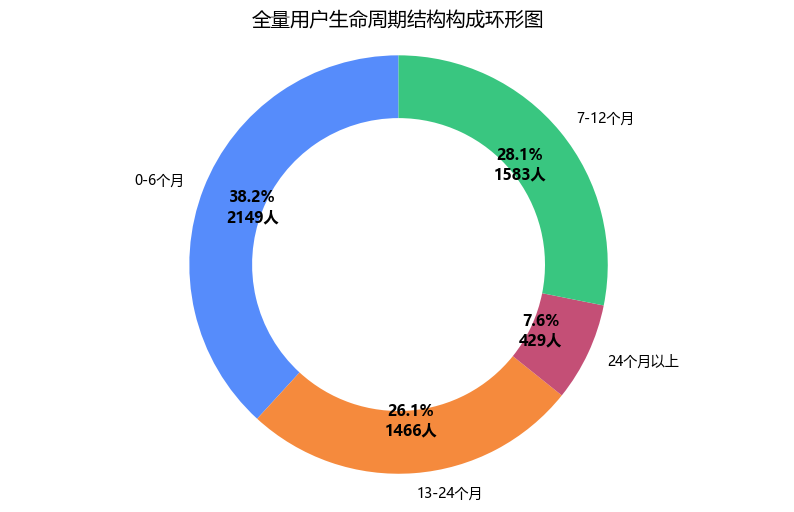

已输出： output\day06_visualization\04_composition_chart.png


In [71]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
labels = composition_summary[composition_field]
sizes = composition_summary["用户数"]
percents = composition_summary["占比"]
composition_path = OUTPUT_DIR / "04_composition_chart.png"
wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n{int(pct/100 * total_user)}人",
    pctdistance=0.75,
    wedgeprops={"width": 0.3},  # 环形宽度，实现环形图
    startangle=90
)

# 美化文字
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax_composition.set_title("全量用户生命周期结构构成环形图", fontsize=14)
ax_composition.axis("equal")  # 保证正圆

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：平台整体用户结构以 0-6 个月新用户占比最高，7-12 个月、13-24 个月用户占比接近，24 个月以上长期留存老用户占比最低，平台用户群体偏新客。
- 证据：总用户规模 5630 人；0-6 个月 2149 人，占比 38.2%；7-12 个月 1583 人，占比 28.1%；13-24 个月 1466 人，占比 26.1%；24 个月以上仅 429 人，占比 7.6%。0-12 个月新用户合计占平台总用户 66.3%。
- 边界：请说明该图适合或不适合进行哪些比较。
- 仅展示全部用户的人数结构分布，无法单独展示流失人群内部结构；仅体现人数占比，不区分各组消费价值与流失风险；属于静态横截面数据，不能反映用户结构随时间的动态变化。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [72]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


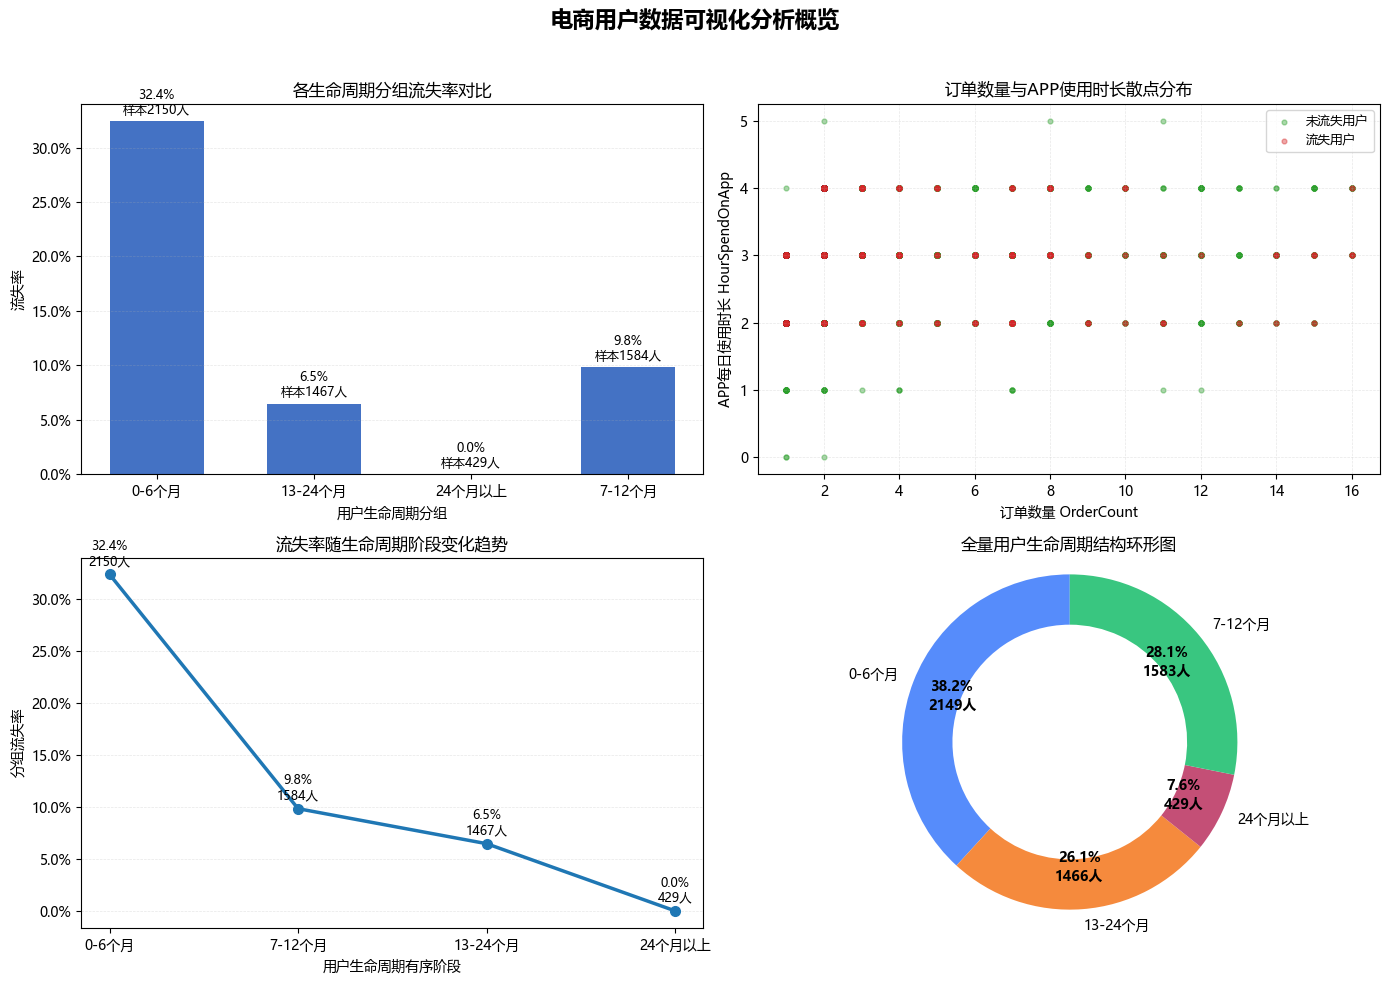

已输出： output\day06_visualization\day06_visualization_summary.png


In [73]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
ax_bar, ax_scatter = axes[0, 0], axes[0, 1]
ax_line, ax_pie = axes[1, 0], axes[1, 1]

# ====================== 子图1：左上 类别对比柱状图(流失率-TenureGroup) ======================
bars = ax_bar.bar(
    x=category_summary["TenureGroup"],
    height=category_summary["流失率"],
    color="#4472C4",
    width=0.6
)
# 标注流失率+样本量
for bar, user_cnt, churn_rate in zip(bars, category_summary["用户数"], category_summary["流失率"]):
    height = bar.get_height()
    label_text = f"{churn_rate:.1%}\n样本{int(user_cnt)}人"
    ax_bar.text(bar.get_x() + bar.get_width()/2, height + 0.004, label_text, ha="center", va="bottom", fontsize=9)
ax_bar.set_title("各生命周期分组流失率对比", fontsize=12)
ax_bar.set_xlabel("用户生命周期分组")
ax_bar.set_ylabel("流失率")
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_bar.grid(axis="y", alpha=0.3, linestyle="--")

# ====================== 子图2：右上 行为散点图(OrderCount & HourSpendOnApp 区分Churn) ======================
# 未流失 Churn=0
df_no_churn = df[df["Churn"] == 0]
ax_scatter.scatter(df_no_churn["OrderCount"], df_no_churn["HourSpendOnApp"], c="#2ca02c", alpha=0.4, label="未流失用户", s=12)
# 流失 Churn=1
df_churn = df[df["Churn"] == 1]
ax_scatter.scatter(df_churn["OrderCount"], df_churn["HourSpendOnApp"], c="#d62728", alpha=0.4, label="流失用户", s=12)
ax_scatter.set_title("订单数量与APP使用时长散点分布", fontsize=12)
ax_scatter.set_xlabel("订单数量 OrderCount")
ax_scatter.set_ylabel("APP每日使用时长 HourSpendOnApp")
ax_scatter.legend(fontsize=9)
ax_scatter.grid(alpha=0.3, linestyle="--")

# ====================== 子图3：左下 有序折线图(流失率生命周期趋势) ======================
ax_line.plot(
    ordered_summary["TenureGroup"],
    ordered_summary["流失率"],
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    markersize=7
)
# 标注数值样本量
for idx, row in ordered_summary.iterrows():
    rate = row["流失率"]
    cnt = row["用户数"]
    ax_line.text(idx, rate + 0.006, f"{rate:.1%}\n{int(cnt)}人", ha="center", va="bottom", fontsize=9)
ax_line.set_title("流失率随生命周期阶段变化趋势", fontsize=12)
ax_line.set_xlabel("用户生命周期有序阶段")
ax_line.set_ylabel("分组流失率")
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.grid(axis="y", alpha=0.3, linestyle="--")

# ====================== 子图4：右下 环形构成图(用户生命周期结构) ======================
labels = composition_summary["TenureGroup"]
sizes = composition_summary["用户数"]
total_user = composition_summary["用户数"].sum()
wedges, texts, autotexts = ax_pie.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n{int(pct/100 * total_user)}人",
    pctdistance=0.75,
    wedgeprops={"width":0.3},
    startangle=90
)
# 修复文字看不清，改为黑色加粗
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(10)
    autotext.set_weight("bold")
for txt in texts:
    txt.set_fontsize=11
ax_pie.set_title("全量用户生命周期结构环形图", fontsize=12)
ax_pie.axis("equal")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限
1.综合发现1：用户生命周期越长，流失风险持续走低，新用户是平台核心流失群体

证据：1)柱状图和折线图显示：0-6 个月新用户流失率 32.4%（样本 2150 人），7-12 个月流失率 9.8%（样本 1584 人），13-24 个月流失率 6.5%（样本 1467 人），24 个月以上老用户流失率 0%（样本 429 人）；

2)生命周期每递进一个阶段，流失率均出现明显下滑，新用户前半年流失风险是成熟老用户的 5 倍以上；

3)环形构成图补充：0-12 个月新用户合计占平台总用户 66.3%，高流失人群在用户池内占比过半，是平台留存运营重点。

2. 综合发现2：用户订单活跃度、APP 使用时长与流失状态高度相关，低行为活跃度用户更容易流失。

证据：1)散点图可见：订单数量偏低（OrderCount＜8）、APP 每日使用时长 2–4 小时的区间，红色流失用户散点大量聚集；

2)高订单数量（OrderCount＞10）、APP 时长低于 1 小时或高于 4 小时的样本基本以绿色未流失用户为主；

3)低频下单、中等 APP 停留时长是流失高风险行为组合，高频消费用户留存稳定性更强。

3. 综合发现3：平台用户结构严重偏向短期新客，长期成熟老用户存量稀缺，用户成熟度结构失衡

证据：1）环形构成图数据：0-6 个月用户占总用户 38.2%，7-12 个月占 28.1%，13-24 个月占 26.1%，24 个月以上仅 7.6%；

2）累计 66.3% 的用户集中在上线 1 年内，使用超过 2 年的忠实用户不足一成；

3）结合流失率数据可知：平台大量用户处于高流失窗口期，存量用户池缺乏稳定高留存老客支撑。

4. 数据或方法局限：

1)仅为横截面静态数据，所有图表均是同一时间点不同人群对比，无法追踪单个用户从新用户到老用户的真实留存变化，生命周期与流失仅能证明相关，无法判定因果；

2)未纳入投诉、返现金额 CashbackAmount、满意度等变量联合分析，无法区分各因素对流失的独立影响权重；

3)缺少时间序列数据，无法判断用户结构、流失率随月份 / 季度的动态变化，不能识别季节性流失波动；

4)未单独拆分「流失用户内部生命周期结构」，仅展示全量用户分布，无法定位流失人群的核心来源结构；

5)散点图仅选取订单数、APP 时长两个行为指标，存在变量遗漏，无法完整刻画用户流失的全部行为特征。
注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [74]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同用户生命周期分组的流失率是否存在显著差异？", "chart_type": "bar", "key_finding": "用户使用时长越短流失率越高，0-6个月新用户流失率32.4%为全组最高，24个月以上用户无流失", "limitation": "仅展示分组横截面对比，无法证明生命周期长短是流失的直接因果，未纳入投诉、消费行为等干扰变量"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "用户平均订单数与APP每日使用时长两个行为指标和用户流失率存在什么关联？", "chart_type": "scatter", "key_finding": "低订单量、中等APP使用时长区间流失用户高度聚集；高订单、极低/极高APP时长的用户基本全部留存", "limitation": "仅能体现变量相关关系，无法量化两个指标对流失的影响权重，缺少满意度、优惠券等其他行为特征"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "随着用户生命周期阶段有序递进，流失率会发生怎样的变化趋势？", "chart_type": "line", "key_finding": "流失率随生命周期延长持续单调下降，前期0-12个月流失降幅最大，长期老用户不存在流失现象", "limitation": "属于静态人群阶段对比，不是追踪同一批用户的真实时间序列，无法反映单用户长期留存变化"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "全量用户在各生命周期阶段的人数结构占比如何分布？", "chart_type": "pie_or_bar", "key_finding": "平台66.3%用户集中在0-12个月新客阶段，24个月以上忠实老用户仅占7.6%，用户结构偏短期新客", "limitation": "仅展示全部用户结构，无法单独拆分流失用户内部构成；仅统计人数，不反映各组消费价值、返现金额等营收指标"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "四大图表联合验证：新用户是核心流失群体，消费活跃度与留存强相关，平台存量用户成熟度结构失衡", "limitation": "全部数据为同一时间横截面，缺少时序数据；CashbackAmount仅为补贴金额，不能用于评估平台营收与GMV损失"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户生命周期分组的流失率是否存在显著差异？,bar,用户使用时长越短流失率越高，0-6个月新用户流失率32.4%为全组最高，24个月以上用户无流失,仅展示分组横截面对比，无法证明生命周期长短是流失的直接因果，未纳入投诉、消费行为等干扰变量
1,02,02_behavior_scatter.png,用户平均订单数与APP每日使用时长两个行为指标和用户流失率存在什么关联？,scatter,低订单量、中等APP使用时长区间流失用户高度聚集；高订单、极低/极高APP时长的用户基本全部留存,仅能体现变量相关关系，无法量化两个指标对流失的影响权重，缺少满意度、优惠券等其他行为特征
2,03,03_ordered_line.png,随着用户生命周期阶段有序递进，流失率会发生怎样的变化趋势？,line,流失率随生命周期延长持续单调下降，前期0-12个月流失降幅最大，长期老用户不存在流失现象,属于静态人群阶段对比，不是追踪同一批用户的真实时间序列，无法反映单用户长期留存变化
3,04,04_composition_chart.png,全量用户在各生命周期阶段的人数结构占比如何分布？,pie_or_bar,平台66.3%用户集中在0-12个月新客阶段，24个月以上忠实老用户仅占7.6%，用户结构偏...,仅展示全部用户结构，无法单独拆分流失用户内部构成；仅统计人数，不反映各组消费价值、返现金额等...
4,05,day06_visualization_summary.png,整体概览,dashboard,四大图表联合验证：新用户是核心流失群体，消费活跃度与留存强相关，平台存量用户成熟度结构失衡,全部数据为同一时间横截面，缺少时序数据；CashbackAmount仅为补贴金额，不能用于评...


In [75]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
